In [1]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# import some libraries for training
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, brier_score_loss
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

from helper_modules import phase1_preprocess_data

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)


### Read in training data and preprocess

In [2]:
df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
# df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train_extended.csv'))
display(df.head())
display(df.groupby("Demand_Response_Flag")['Site'].count())

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


Demand_Response_Flag
-1      2262
 0    102011
 1       847
Name: Site, dtype: int64

In [3]:
# perform some preprocessing
df = phase1_preprocess_data(df)
display(df.head(), df.tail())

,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Hour,Day,DOW,Month,Weekday,Minute,Hour_sin,Hour_cos,DOW_sin,DOW_cos,HDD18,CDD22,TempC2,rad_sqrt,rad_log1p,is_daylight,TempC_x_daylight,CDD22_x_daylight,Is_Weekend,Is_Summer,Is_Winter,Is_Afternoon,Is_Evening
0,22.20,0.0,4.8,0,0,1,1,1,1,0,0.000000,1.000000,0.781831,0.62349,0.0,0.20,492.8400,0.0,0.0,0,0.0,0.0,0,0,1,0,0
1,22.27,0.0,4.8,0,0,1,1,1,1,15,0.000000,1.000000,0.781831,0.62349,0.0,0.27,495.9529,0.0,0.0,0,0.0,0.0,0,0,1,0,0
2,22.35,0.0,4.8,0,0,1,1,1,1,30,0.000000,1.000000,0.781831,0.62349,0.0,0.35,499.5225,0.0,0.0,0,0.0,0.0,0,0,1,0,0
3,22.42,0.0,4.8,0,0,1,1,1,1,45,0.000000,1.000000,0.781831,0.62349,0.0,0.42,502.6564,0.0,0.0,0,0.0,0.0,0,0,1,0,0
4,22.50,0.0,4.8,0,1,1,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.0,0.50,506.2500,0.0,0.0,0,0.0,0.0,0,0,1,0,0


,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Hour,Day,DOW,Month,Weekday,Minute,Hour_sin,Hour_cos,DOW_sin,DOW_cos,HDD18,CDD22,TempC2,rad_sqrt,rad_log1p,is_daylight,TempC_x_daylight,CDD22_x_daylight,Is_Weekend,Is_Summer,Is_Winter,Is_Afternoon,Is_Evening
105115,20.57,0.0,56.33,0,22,31,6,12,6,45,-0.500000,0.866025,-0.781831,0.62349,0.0,0.0,423.1249,0.0,0.0,0,0.0,0.0,1,0,1,0,1
105116,20.60,0.0,56.33,0,23,31,6,12,6,0,-0.258819,0.965926,-0.781831,0.62349,0.0,0.0,424.3600,0.0,0.0,0,0.0,0.0,1,0,1,0,1
105117,20.75,0.0,56.33,0,23,31,6,12,6,15,-0.258819,0.965926,-0.781831,0.62349,0.0,0.0,430.5625,0.0,0.0,0,0.0,0.0,1,0,1,0,1
105118,20.90,0.0,56.33,0,23,31,6,12,6,30,-0.258819,0.965926,-0.781831,0.62349,0.0,0.0,436.8100,0.0,0.0,0,0.0,0.0,1,0,1,0,1
105119,21.05,0.0,56.33,0,23,31,6,12,6,45,-0.258819,0.965926,-0.781831,0.62349,0.0,0.0,443.1025,0.0,0.0,0,0.0,0.0,1,0,1,0,1


In [4]:
cont_cols =['Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
            'Hour', 'Day', 'DOW', 'Month', 'Weekday', 'Minute',
            'Hour_sin', 'Hour_cos', 'DOW_sin', 'DOW_cos', 'HDD18', 'CDD22', 'TempC2', 'rad_sqrt',
            'rad_log1p', 'TempC_x_daylight', 'CDD22_x_daylight']
binary_cols = [c for c in df.columns if c not in cont_cols + ['Demand_Response_Flag']]
columns_dict = {
    'continuous' : cont_cols,
    'binary'    : binary_cols
}

### Functions for Neural Network training

In [5]:
# Some classes and functions for training

# Define the neural network architecture: Just need to load architecture from net_architecture.py
# see the file for details
from net_architecture import Net


# Define Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        # calculate focal loss (using cross-entropy loss)
        # but this form of focal loss is more numerically stable
        # What it does: FocusLoss suppress majority class loss, focus more on minority class loss
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss
        

# Standardize features and split data
def standardize_data(X_train, X_test, cols_dict=None):
    """
    Remark: Since our features have a lot of zeros, using standard-scaler will not help much because
    the mean will be very close to zero, and std will be very large, so most of the values will be very close to zero after standardization.
    Therefore, we will use:
    - Yeo-Johnson transformation to make the data more Gaussian-like, 
    - then StandardScaler.
    Use ColumnTransformer to apply different scalers to different columns
    """
    binary_cols = cols_dict['binary']
    cont_cols   = cols_dict['continuous']
    # create the column transformer
    scaler = ColumnTransformer(
        transformers=[
            ("bin_pass", "passthrough", binary_cols),
            ("yj_std", Pipeline([
                ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False)),
                ("std", StandardScaler())
            ]), cont_cols),
        ],
        remainder="drop"
    )
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, scaler


# prepare data for training (train_loader, test_loader)
def prepare_data(X_train, y_train, X_test, y_test, batch_size=1024):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    # create datasets and dataloaders
    #------------------------------------------------------
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    #------------------------------------------------------
    test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    #------------------------------------------------------
    return train_loader, test_loader


def generate_criterion(y_train, loss_type='cross_entropy'):
    # 1. Calculate class weights to handle class imbalance
    class_weights_tensor = torch.tensor(
        compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train), 
        dtype=torch.float32
    )
    # 2. Choose which loss function to use
    if loss_type == 'cross_entropy':
        # Standard CrossEntropyLoss with class weights
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    elif loss_type == 'focal':
        # Use class_weights_tensor as alpha for Focal Loss
        criterion = FocalLoss(alpha=class_weights_tensor, gamma=2)
    return criterion


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_loss):
        if self.best_loss is None or current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop
    

# training function
def train_model(model, train_loader, test_loader, criterion, optimizer, es, epochs=50):
    """
    Train the model with early stopping.
    Args:
        model: The neural network model to train.
        train_loader: DataLoader for training data.
        test_loader: DataLoader for validation data.
        criterion: Loss function.
        optimizer: Optimizer for training.
        es: EarlyStopping object.
        epochs: Maximum number of epochs to train.
    Returns:
        The best model based on validation/test loss.
    """
    best_test_loss = float('inf')
    history = {'train_loss': [], 'test_loss': []}
    for epoch in range(epochs):
        # Train model for each epoch
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        # Evaluate on test set
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * inputs.size(0)
            test_loss /= len(test_loader.dataset)
        # record history
        avg_train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(test_loss)
        # Early stopping
        improved = test_loss < best_test_loss - (es.min_delta if es else 0.0)
        if improved:
            best_test_loss = test_loss
            torch.save(model.state_dict(), './models/phase1_nn_model.pth')
        should_stop = es.step(test_loss) if es else False
        if should_stop:
            print(f"Early stopping triggered @ epoch {epoch}.")
            break
        # print training log
        if (epoch + 1) % 10 == 0:
            avg_loss = running_loss / len(train_loader.dataset)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Loss: {test_loss:.4f}")    
    # return the best model
    return model, history


# evaluation function
def evaluate_model(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    check_acc = torch.tensor(all_preds) == torch.tensor(all_labels)
    accuracy = (check_acc).float().mean().item()
    print(f"Test Accuracy: {accuracy:.4f}")
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Weighted F1 Score: {f1:.4f}")

### Perform training of Neural Networks
- Prepare features and target
- Train/Test split
- Features standardization
- Prepare NN inputs parameters
- Create torch loaders for train/test
- Create criterion (CrossEntropy or Focal)
- Create optimizer & early stopping objects
- Train
- Evaluate (quick)

In [6]:
# Assume the target column is 'Demand_Response_Flag' (3 classes: 0, 1, 2)
# If not, replace with the correct target column

# Prepare features and target
X = df.drop(columns=['Demand_Response_Flag'])
y = df['Demand_Response_Flag'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=100/len(y), random_state=42, stratify=y
)

# Standardize features
# scaler = RobustScaler() # StandardScaler()
# X_scaled = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# X_scaled = X

# perform standardization only on continuous columns
X_train, X_test, scaler = standardize_data(X_train, X_test, cols_dict=columns_dict)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# Preparations for trainings
input_dim = X_train.shape[1]
num_classes = np.unique(y_train).shape[0]
n_epochs = 500
batch_sz = 1024
lr_ = 5e-4
w_decay = 5e-3
es_patience, es_thres = 20, 5e-4  # early stopping patience & thresholds

# configure data loader and batch size
# 1. convert data to torch tensors
# 2. create datasets and dataloaders
train_loader, test_loader = prepare_data(X_train, y_train, X_test, y_test, batch_size=batch_sz)

# create a neural net model
model = Net(input_dim, num_classes)

# generate criterion (loss function)
# for imbalanced dataset, recommend to use focal loss
# criterion = generate_criterion(y_train, loss_type='cross_entropy')
criterion = generate_criterion(y_train, loss_type='focal')

# configure optimizer
optimizer = optim.Adam(model.parameters(), lr=lr_, weight_decay=w_decay)

# configure early stopping
early_stopping = EarlyStopping(patience=es_patience, min_delta=es_thres)

# Train the model
model, history = train_model(model, train_loader, test_loader, criterion, optimizer, early_stopping, epochs=n_epochs)

# Evaluate the model
evaluate_model(model, test_loader)

X_train shape: (105020, 26), X_test shape: (100, 26)
Epoch 10/500, Loss: 0.2082, Test Loss: 0.2016
Epoch 20/500, Loss: 0.1650, Test Loss: 0.1424
Epoch 30/500, Loss: 0.1464, Test Loss: 0.4163
Epoch 40/500, Loss: 0.1423, Test Loss: 0.0817
Epoch 50/500, Loss: 0.1234, Test Loss: 0.0686
Epoch 60/500, Loss: 0.1167, Test Loss: 0.0787
Epoch 70/500, Loss: 0.1274, Test Loss: 0.0905
Early stopping triggered @ epoch 71.
Test Accuracy: 0.7800
Weighted F1 Score: 0.8524


### Save models

In [7]:
# Save the scaler to a pkl file
joblib.dump(scaler, './models/phase1_scaler.pkl')
joblib.dump(cont_cols, './models/phase1_cont_cols.pkl')
joblib.dump(binary_cols, './models/phase1_binary_cols.pkl')
# Save the trained model to a file
torch.save(model.state_dict(), './models/phase1_nn_model.pth')

# Load the trained model from file
model_loaded = Net(input_dim, num_classes)
model_loaded.load_state_dict(torch.load('./models/phase1_nn_model.pth'))
model_loaded.eval()

Net(
  (fc1): Linear(in_features=26, out_features=64, bias=True)
  (relu): ReLU()
  (gelu): GELU(approximate='none')
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (fc5): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

### Perform models evaluation

Distribution in predicted: {0: 75, 1: 8, 2: 17}
Brier scores per class: {0: 0.2237893752561161, 1: 0.05333027603470139, 2: 0.13015236615799544}


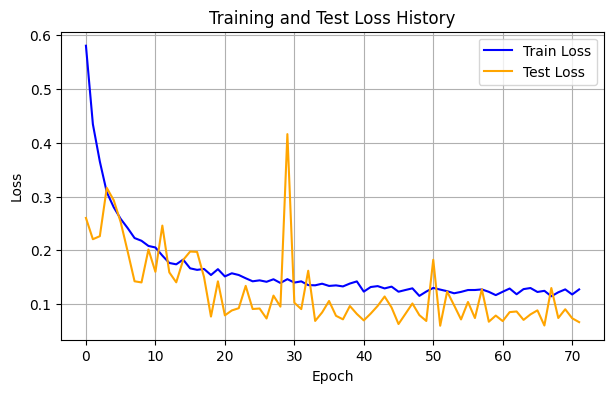

In [8]:
# Generate predictions and calculate distribution of predicted classes
model_loaded.eval()
predicted, probs = [], []
with torch.no_grad():
    for inputs, _ in test_loader:
        outputs = model_loaded(inputs)
        # calculate predicted classes
        _, preds = torch.max(outputs, 1)
        predicted.extend(preds.cpu().numpy())
        # calculate predicted probabilities
        prob = torch.softmax(outputs, dim=1)
        probs.append(prob.cpu().numpy())
predicted = torch.tensor(predicted)
probs = np.concatenate(probs, axis=0)
# compute distribution of predicted classes
unique_pred, counts_pred = torch.unique(predicted, return_counts=True)
distribution_pred = dict(zip(unique_pred.tolist(), counts_pred.tolist()))
print("Distribution in predicted:", distribution_pred)
# Compute Brier score for each class (this is to check model calibration quality)
brier_scores = {}
for i in range(num_classes):
    brier_scores[i] = brier_score_loss((y_test == i).astype(int), probs[:, i])
print("Brier scores per class:", brier_scores)

# Plot loss history
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], c='blue'  , label='Train Loss')
plt.plot(history['test_loss'] , c='orange', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss History')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Calculate distribution of classes in y_train
unique_train, counts_train = np.unique(y_train, return_counts=True)
distribution_y_train = dict(zip(unique_train.tolist(), counts_train.tolist()))
print("Distribution in y_train:", distribution_y_train)

Distribution in y_train: {0: 101914, 1: 846, 2: 2260}
